# Análisis de la data del Titanic # 

Importando librerias para el análisis de los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

Creando dataset de Titanic

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.tail(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5000,NaN,S
842,843,1,1,"Serepeca, Miss. Augusta",female,30.0,0,0,113798,31.0000,NaN,C
843,844,0,3,"Lemberopolous, Mr. Peter L",male,34.5,0,0,2683,6.4375,NaN,C
844,845,0,3,"Culumovic, Mr. Jeso",male,17.0,0,0,315090,8.6625,NaN,S
845,846,0,3,"Abbing, Mr. Anthony",male,42.0,0,0,C.A. 5547,7.5500,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S
847,848,0,3,"Markoff, Mr. Marin",male,35.0,0,0,349213,7.8958,NaN,C
848,849,0,2,"Harper, Rev. John",male,28.0,0,1,248727,33.0000,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,NaN,S


In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df["Survived"].value_counts(normalize=True)*100.  #MCuente el total de valos de la columna "Survived" en este caso

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [11]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Cuántas mujeres y hombres sobrevivieron

In [12]:
df[df["Survived"]==1].groupby("Sex")["Survived"].sum()

Sex
female    233
male      109
Name: Survived, dtype: int64

Cuántas mujeres y hombres murieron

In [13]:
df[df["Survived"]==0].groupby("Sex")["Survived"].count()

Sex
female     81
male      468
Name: Survived, dtype: int64

Cuátas de las personas que embarcaron por S sobrevivieron

In [14]:
df[df["Embarked"]=="S"].groupby("Embarked")["Survived"].sum()

Embarked
S    217
Name: Survived, dtype: int64

¿Cuál fue la edad promedio (Age) de las personas que murieron vs las que sobrevivieron?

In [15]:
df[df["Survived"]==0]["Age"].mean()

np.float64(30.62617924528302)

promedio de edad de las mujeres que sobrevivieron

In [16]:
df[(df["Survived"]==1) & (df["Sex"]=="female")]["Age"].mean()

np.float64(28.84771573604061)

In [17]:
df[((df["Survived"]==1) & (df["Age"]>50)) & (df["Fare"]>100)].groupby(["Pclass", "Sex"])["Survived"].count()

Pclass  Sex   
1       female    2
Name: Survived, dtype: int64

In [18]:
df[(df["Sex"] == "male") & (df["Age"]>60) & (df["Pclass"]==3)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


## GRÁFICAS 

<function matplotlib.pyplot.show(close=None, block=None)>

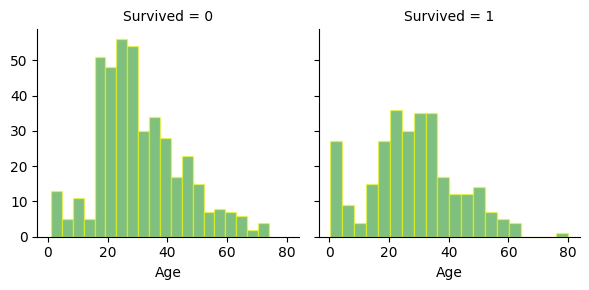

In [19]:
histograma_edades = sb.FacetGrid(df, col="Survived")
histograma_edades.map(plt.hist, "Age", bins=20, color="Green", edgecolor="Yellow",alpha=0.5)
plt.show

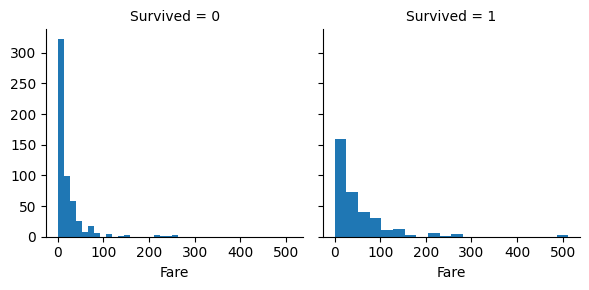

In [20]:
histograma_fare = sb.FacetGrid(df, col="Survived")
histograma_fare.map(plt.hist,"Fare", bins=20 )
plt.show()

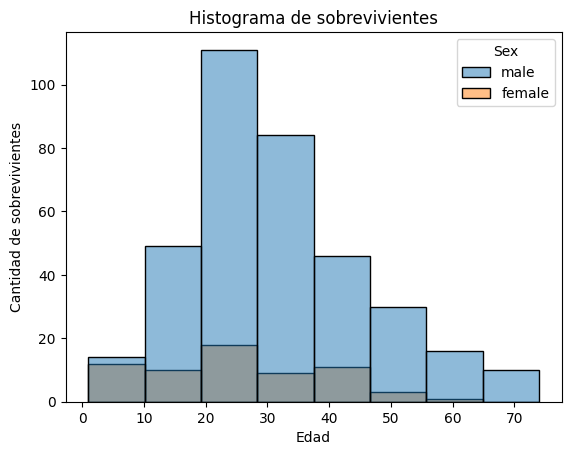

In [21]:
plt.Figure(figsize=(4,8))
sb.histplot(data=df[df["Survived"]==0], x="Age", hue='Sex', bins=8)
plt.title("Histograma de sobrevivientes")
plt.xlabel("Edad")
plt.ylabel("Cantidad de sobrevivientes")
plt.show()

## LIMPIEZA DE DATOS

In [25]:
df=df.drop(["Cabin", "Ticket", "PassengerId", "Name"], axis=1)


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [28]:
df=pd.get_dummies(df, columns=["Sex"], drop_first=False, dtype='uint8')

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         714 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Embarked    889 non-null    str    
 7   Sex_female  891 non-null    uint8  
 8   Sex_male    891 non-null    uint8  
dtypes: float64(2), int64(4), str(1), uint8(2)
memory usage: 50.6 KB


In [32]:
df.isna().sum()

np.int64(0)

In [31]:
df=df["Age"].fillna(df["Age"].median())

In [33]:
df.info()

<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [34]:
df=pd.get_dummies(df, columns=["Embarked"], drop_first=False, dtype='uint8')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 88 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0.42    891 non-null    uint8
 1   0.67    891 non-null    uint8
 2   0.75    891 non-null    uint8
 3   0.83    891 non-null    uint8
 4   0.92    891 non-null    uint8
 5   1.0     891 non-null    uint8
 6   2.0     891 non-null    uint8
 7   3.0     891 non-null    uint8
 8   4.0     891 non-null    uint8
 9   5.0     891 non-null    uint8
 10  6.0     891 non-null    uint8
 11  7.0     891 non-null    uint8
 12  8.0     891 non-null    uint8
 13  9.0     891 non-null    uint8
 14  10.0    891 non-null    uint8
 15  11.0    891 non-null    uint8
 16  12.0    891 non-null    uint8
 17  13.0    891 non-null    uint8
 18  14.0    891 non-null    uint8
 19  14.5    891 non-null    uint8
 20  15.0    891 non-null    uint8
 21  16.0    891 non-null    uint8
 22  17.0    891 non-null    uint8
 23  18.0    891 non-null    ui